# Xopt Bayesian Optimization — Scenarios A, B, C on the real FELsim backend

This notebook mirrors [`scenario_A-C.ipynb`](scenario_A-C.ipynb) — same scenarios, variables,
objectives, bounds, reference currents and success threshold — but solves each matching problem
with **Bayesian Optimization (BO)** using [**Xopt**](https://github.com/xopt-org/Xopt) (SLAC's
optimization framework, BO backed by BoTorch/GPyTorch) instead of `scipy.optimize` methods.

## Scenario A
| Quads | Obj. element(s) | Constraints | Targets |
|---|---|---|---|
| 1, 3 | 8, 9 | (0.01,1.5) | α_x=0(8), α_y=0(9) |


## Scenario B
| Quads | Obj. element(s) | Constraints | Targets |
|---|---|---|---|
| 1, 3 | 8, 9 | (0.01,5.0) | α_x=α_y=0 |
| 10 | 15 | (0.01,5.0) | D_x=0 |
| 16, 18, 20 | 25, 26 | (0.01,1.5) | α_x=α_y=0 |
| 27 | 32 | (0.01,5.0) | D_x=0 |
| 37, 35, 33 | 37 | (0.01,5.0) | α_x=α_y=0, E_x=E_y=2 mm (+ mirror 39,41,43) |
| 50 | 55 | (0.01,5.0) | D_x=0 |
| 56, 58 | 59 | (0.01,5.0) | E_x=E_y=0 (IP focus) |
| 61, 63 | 68, 69 | (0.01,5.0) | α_x=α_y=0 |
| 70 | 75 | (0.01,5.0) | D_x=0 |
| 76, 78, 80 | 85, 86 | (0.01,5.0) | α_x=α_y=0 |
| 87, 93, 95, 97 | 92, 117 | (0.01,5.0) | D_x=0 at el.92 + β_x=1.4, β_y=0.24, α_x=0.47, α_y=0 at UND |

## Scenario C
| Quads | Obj. element(s) | Constraints | Targets |
|---|---|---|---|
|56, 58, 61, 63, 76, 78, 80, 87, 93, 95, 97 | 59, 117 | (0.01,5.0) | E_x=E_y=0(59), β_x=1.4, β_y=0.24, α_x=0.47, α_y=0(117) |


Everything runs on the **actual FELsim backend** (`experiments_utils` / `configs`, exactly as
`scenario_A-C.ipynb`). Common settings: `CURRENT_BOUNDS = (0.01, 1.5)` A, `EPSILON = 1e-3` on the
weighted MSE, `SEED = 42`.

```bash
pip install xopt
```

In [6]:
import os, sys, copy, time, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore")

# FELsim backend + beam / lattice constants (same import path as scenario_A-C.ipynb)
sys.path.append(os.path.join(os.getcwd(), ".."))
sys.path.append(os.path.join(os.getcwd(), "../.."))
from experiments_utils import (PARTICLES, EXCEL_PATH, ExcelElements, beamOptimizer,
                               ALPHA_XM, ALPHA_YM, BETA_XM, BETA_YM)
from configs import *

from xopt import Xopt, Evaluator, VOCS
from xopt.generators.bayesian import ExpectedImprovementGenerator

from utils.Xopt_utils import *

import importlib
import utils.Xopt_utils
importlib.reload(utils.Xopt_utils)
from utils.Xopt_utils import *

# CURRENT_BOUNDS = (0.01, 1.5)     # same bounds as scenario_A-C.ipynb
# EPSILON        = 1e-3            # success threshold on the raw MSE
# SEED           = 42
# XOPT_TAG       = "Xopt-EI"       # 'method_tag' used in the result tables

# bl_full = ExcelElements(EXCEL_PATH).create_beamline()
# print(f"FELsim beamline: {len(bl_full)} elements | particles: {tuple(PARTICLES.shape)}")
# print(f"UND matching targets: alpha_x={ALPHA_XM}, alpha_y={ALPHA_YM}, "
#       f"beta_x={BETA_XM} m, beta_y={float(BETA_YM):.4f} m")

In [ ]:
# def _v(name):
#     """Variable spec understood by beamOptimizer: [name, attribute, x -> attribute value]."""
#     return [name, "current", lambda x, _n=name: x]


# def measured_names(obj):
#     """Column names of the measured quantities, e.g. '8_alpha_x' (same convention as experiments_utils)."""
#     return [f"{elem}_{t['measure'][1]}_{t['measure'][0]}" for elem, targets in obj.items() for t in targets]


# def make_felsim_evaluator(beamline, seg_var, obj, bounds=CURRENT_BOUNDS, particles=PARTICLES):
#     """
#     Wrap a FELsim beamline slice into an Xopt-compatible ``evaluate(inputs) -> dict``.

#     Returns ``(evaluate, var_names, out_names)``.  ``evaluate`` returns
#       - 'MSE' : the raw weighted MSE — the BO objective, identical to what scipy minimises
#                 in scenario_A-C.ipynb (no log transform)
#       - one entry per measured quantity, named like '8_alpha_x'
#     Any exception / non-finite MSE is reported as NaN, so Xopt simply skips that point.
#     """
#     var_names = list(dict.fromkeys(v[0] for v in seg_var.values()))      # spec order, unique
#     out_names = measured_names(obj)

#     opti = beamOptimizer(beamline, particles.clone())
#     start_point = {n: {"bounds": tuple(bounds), "start": 1.0} for n in var_names}
#     opti._prepare(seg_var, start_point, copy.deepcopy(obj))              # set-up only, no optimisation
#     order = list(opti.variablesToOptimize)                               # beamOptimizer's internal (set) order
#     flat_goals = [g for elem in opti.objectives for g in opti.objectives[elem]]

#     def evaluate(inputs: dict) -> dict:
#         out = {"MSE": np.nan, **{n: np.nan for n in out_names}}
#         try:
#             x = np.array([float(inputs[n]) for n in order])
#             mse = float(opti._optiSpeed(x))
#             if np.isfinite(mse):
#                 out["MSE"] = mse
#                 for name, g in zip(out_names, flat_goals):
#                     val = g["measured"]
#                     out[name] = float(val.item() if hasattr(val, "item") else val)
#         except Exception:
#             pass                                                        
#         return out

#     return evaluate, var_names, out_names


# def run_xopt_bo(evaluate, var_names, n_init, n_steps, seed=SEED, bounds=CURRENT_BOUNDS,
#                 label="", verbose=True, print_every=5):
#     """
#     Random initialisation + Expected-Improvement BO loop (same recipe as Scenario A above),
#     on the raw MSE objective.  Returns the Xopt object and a stats dict.
#     """
#     vocs = VOCS(variables={n: list(bounds) for n in var_names},
#                 objectives={"MSE": "MINIMIZE"})
#     X = Xopt(evaluator=Evaluator(function=evaluate),
#              generator=ExpectedImprovementGenerator(vocs=vocs), vocs=vocs)

#     torch.manual_seed(seed)                       # reproducible GP fits / acquisition optimisation
#     t0 = time.perf_counter()
#     X.random_evaluate(n_init, seed=seed)          # phase 1: random exploration
#     n_fallback = 0
#     for i in range(n_steps):                      # phase 2: fit GP -> maximise EI -> evaluate
#         try:
#             X.step()
#         except Exception:                         # e.g. GP fit on degenerate data -> random point instead
#             n_fallback += 1
#             X.random_evaluate(1, seed=seed + 1000 + i)
#         if verbose and print_every and (i + 1) % print_every == 0:
#             print(f"      {label:18s} BO step {i + 1:3d}/{n_steps}   best MSE = {X.data['MSE'].min():.3e}")
#     wall = time.perf_counter() - t0

#     mse = X.data["MSE"].to_numpy(dtype=float)
#     n_ok = int(np.isfinite(mse).sum())
#     if n_ok:
#         best_pos = int(np.nanargmin(mse))
#         best = X.data.iloc[best_pos]
#         hist = np.minimum.accumulate(np.nan_to_num(mse, nan=np.inf))
#         n_to_eps = int(np.argmax(hist < EPSILON)) + 1 if np.any(hist < EPSILON) else None
#         best_x = {n: float(best[n]) for n in var_names}
#         final_mse = float(best["MSE"])
#     else:                                         # every evaluation failed
#         best_pos, n_to_eps, best_x, final_mse = -1, None, {n: np.nan for n in var_names}, np.nan
#     stats = {
#         "final_mse": final_mse,
#         "best_x": best_x,
#         "best_eval": best_pos + 1,
#         "nfev": int(len(X.data)),
#         "n_failed": int(len(X.data) - n_ok),
#         "n_fallback": n_fallback,
#         "n_to_eps": n_to_eps,
#         "wall_time": round(wall, 3),
#         "success": bool(np.isfinite(final_mse) and final_mse < EPSILON),
#     }
#     return X, stats


# def bo_convergence_plot(ax, data, n_init, title=None, eps=EPSILON):
#     """Evaluations + best-so-far MSE on a log axis (same style as the Scenario A plot above)."""
#     mse = np.nan_to_num(data["MSE"].to_numpy(dtype=float), nan=np.inf)
#     ev = np.arange(1, len(mse) + 1)
#     ok = np.isfinite(mse)
#     ax.semilogy(ev[ok], mse[ok], "o", ms=4, mfc="#9ecae1", mec="white", mew=0.7, label="evaluation")
#     ax.semilogy(ev, np.minimum.accumulate(mse), drawstyle="steps-post", color="#1f4e79", lw=1.8, label="best so far")
#     ax.axhline(eps, color="#c44e52", lw=1.1, ls="--", label=f"EPSILON = {eps:g}")
#     ax.axvline(n_init + 0.5, color="gray", lw=0.9, ls=":", label="BO starts")
#     if title:
#         ax.set_title(title, fontsize=9)
#     ax.grid(alpha=0.25, which="both")
#     ax.tick_params(labelsize=8)

## Scenario A parameters

In [ ]:
# # ---- Scenario A parameters (identical to scenario_A-C.ipynb) ----
# # A_BEAMLINE_LEN = 10                 # optimise on the first 10 beamline elements

# REF_I_1 = FELSIM_S1_CURRENTS[1]
# REF_I_3 = FELSIM_S1_CURRENTS[3]
# REF_I   = [REF_I_1, REF_I_3]

# A_VARS = {                         
#     1: ["I",  "current", lambda x: x],
#     3: ["I2", "current", lambda x: x],
# }
# A_OBJ = {                          
#     8: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
#     9: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
# }

# # ---- Bayesian-optimization budget ----
# N_INIT_A     = 5                      # random initial evaluations
# N_BO_STEPS = 30                     # BO iterations (1 FELsim evaluation per step)

## Xopt setup: VOCS + Evaluator + Generator

Xopt splits an optimization into three parts:

- **`VOCS`** — **V**ariables (with bounds), **O**bjectives, **C**onstraints,
  **S**tatics/observables.
- **`Evaluator`** — wraps your black-box `evaluate(inputs: dict) -> dict`
  (can also run parallel/vectorized evaluations).
- **`Generator`** — the algorithm proposing the next point(s). Here
  `ExpectedImprovementGenerator`: a Gaussian-Process surrogate + Expected
  Improvement acquisition.

`Xopt` ties them together; each `X.step()` = *fit GP → maximize acquisition →
evaluate the proposed point → append to `X.data`*. Printing `X` shows the whole
configuration as YAML (which is also how Xopt runs can be fully specified).


In [3]:
# A_var_names = [v[0] for v in A_VARS.values()]  
evaluate_A, A_var_names, A_out_names = make_felsim_evaluator(bl_full[:A_BEAMLINE_LEN], A_VARS, A_OBJ)

vocs_A = VOCS(
    variables={name: list(CURRENT_BOUNDS_A) for name in A_var_names},   # {'I': [0.01, 1.5], 'I2': [0.01, 1.5]}
    objectives={"MSE": "MINIMIZE"},                                   # BO target: the raw MSE
)
evaluator_A = Evaluator(function=evaluate_A)
generator_A = ExpectedImprovementGenerator(vocs=vocs_A)

X = Xopt(evaluator=evaluator_A, generator=generator_A, vocs=vocs_A)
print(X)


            Xopt
________________________________
Version: 3.2.1
Data size: 0
Config as YAML:
dump_file: null
evaluator:
  function: utils.Xopt_utils.make_felsim_evaluator.<locals>.evaluate
  function_kwargs: {}
  max_workers: 1
  vectorized: false
generator:
  computation_time: null
  custom_objective: null
  fixed_features: null
  gp_constructor:
    covar_modules: {}
    custom_noise_prior: null
    mean_modules: {}
    name: standard
    train_config: null
    train_kwargs: null
    train_method: lbfgs
    train_model: true
    trainable_mean_keys: []
    transform_inputs: true
    use_cached_hyperparameters: false
    use_low_noise_prior: false
  max_travel_distances: null
  model: null
  n_candidates: 1
  n_interpolate_points: null
  n_monte_carlo_samples: 128
  name: expected_improvement
  numerical_optimizer:
    discrete_max_batch_size: 2048
    discrete_max_choices: 4096
    max_iter: 1000
    max_time: 5.0
    mixed_max_discrete_configurations: 512
    n_restarts: 20
    na

## Run: random initialization + BO loop

Phase 1 seeds the GP with `N_INIT` random points; phase 2 runs `N_BO_STEPS`
Bayesian-optimization steps (one FELsim evaluation each).

In [ ]:
# # torch.manual_seed(SEED)                       # reproducible GP fits / acquisition optimization
# def run_scenario_A_xopt(X, N_INIT_A, N_BO_STEPS_A, SEED):
#     t0 = time.time()
#     X.random_evaluate(N_INIT_A, seed=SEED)          # phase 1: random exploration
#     print(f"random init ({N_INIT_A} pts):    best MSE = {X.data['MSE'].min():.3e}")

#     for i in range(N_BO_STEPS_A):                   # phase 2: fit GP -> maximize EI -> evaluate
#         X.step()
#         if (i + 1) % 5 == 0:
#             print(f"BO step {i + 1:3d}/{N_BO_STEPS_A}:      best MSE = {X.data['MSE'].min():.3e}")

#     print(f"\ndone: {len(X.data)} FELsim evaluations in {time.time() - t0:.1f} s")

In [7]:
run_scenario_A_xopt(X, N_INIT_A, N_BO_STEPS_A, A_out_names,FELSIM_S1_CURRENTS, SEED)

random init (5 pts):    best MSE = 8.405e-02
BO step   5/30:      best MSE = 8.405e-02
BO step  10/30:      best MSE = 7.322e-02
BO step  15/30:      best MSE = 7.322e-02
BO step  20/30:      best MSE = 3.960e-03
BO step  25/30:      best MSE = 3.960e-03
BO step  30/30:      best MSE = 3.960e-03

done: 70 FELsim evaluations in 37.3 s
best found : I = 0.9278,  I2 = 1.1809   (evaluation #56)
reference  : I = 0.8218,  I2 = 1.0430   (FELsim S1 currents)
|delta I|  : 0.1060,  0.1379
alpha_x(8) = +2.3912e-02,   alpha_y(9) = -8.5720e-02
best MSE   : 3.960e-03   (EPSILON = 0.001 -> not converged)


## Results — best point vs. reference

In [ ]:
# best_idx = X.data["MSE"].idxmin()
# best     = X.data.loc[best_idx]

# success = bool(best["MSE"] < EPSILON)
# print(f"best found : I = {best['I']:.4f},  I2 = {best['I2']:.4f}   (evaluation #{X.data.index.get_loc(best_idx) + 1})")
# print(f"reference  : I = {REF_I[0]:.4f},  I2 = {REF_I[1]:.4f}   (FELsim S1 currents)")
# print(f"|delta I|  : {abs(best['I'] - REF_I[0]):.4f},  {abs(best['I2'] - REF_I[1]):.4f}")
# print(f"alpha_x(8) = {best[A_out_names[0]]:+.4e},   alpha_y(9) = {best[A_out_names[1]]:+.4e}")
# print(f"best MSE   : {best['MSE']:.3e}   (EPSILON = {EPSILON:g} -> {'SUCCESS' if success else 'not converged'})")
# if success:
#     hist = np.minimum.accumulate(X.data["MSE"].to_numpy())
#     n_to_eps = int(np.argmax(hist < EPSILON)) + 1
#     print(f"evaluations needed to reach EPSILON: {n_to_eps}"
#           f"   (scenario_A-C.ipynb, 1 run each: Nelder-Mead 84 nfev, L-BFGS-B 60, SLSQP 47, COBYLA 508)")

last 5 evaluations:


,I,I2,8_alpha_x,9_alpha_y,MSE
30,1.048647,0.797427,-3.151692,1.032143,5.499240
31,0.152271,0.010000,0.755765,-2.090093,2.469835
32,0.454341,0.672919,-1.296373,1.507590,1.976705
33,0.010000,0.093421,-1.203303,0.443518,0.822323
34,1.168208,1.321856,-2.054856,-0.613248,2.299253


best found : I = 0.1425,  I2 = 0.1460   (evaluation #24)
reference  : I = 0.8218,  I2 = 1.0430   (FELsim S1 currents)
|delta I|  : 0.6793,  0.8970
alpha_x(8) = -2.1050e-01,   alpha_y(9) = -8.6629e-02
best MSE   : 2.591e-02   (EPSILON = 0.001 -> not converged)


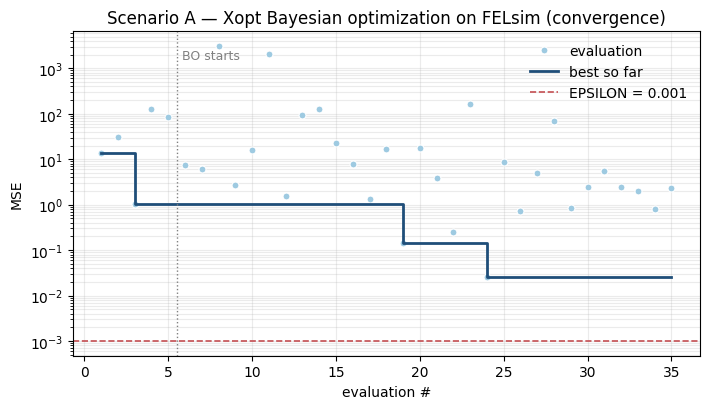

In [ ]:
# def plot_scenario_A_xopt_convergence(X, N_INIT_A):

#     mse_hist    = X.data["MSE"].to_numpy()
#     best_so_far = np.minimum.accumulate(mse_hist)
#     evals       = np.arange(1, len(mse_hist) + 1)
#     fig, ax = plt.subplots(figsize=(7.2, 4.2))
#     ax.semilogy(evals, mse_hist, "o", ms=5, mfc="#9ecae1", mec="white", mew=0.8,
#                 label="evaluation")
#     ax.semilogy(evals, best_so_far, drawstyle="steps-post", color="#1f4e79", lw=2,
#                 label="best so far")
#     ax.axhline(EPSILON, color="#c44e52", lw=1.2, ls="--", label=f"EPSILON = {EPSILON:g}")
#     ax.axvline(N_INIT_A + 0.5, color="gray", lw=1, ls=":")
#     ax.text(N_INIT_A + 0.8, ax.get_ylim()[1] * 0.25, "BO starts", fontsize=9, color="gray")
#     ax.set_xlabel("evaluation #")
#     ax.set_ylabel("MSE")
#     ax.set_title("Scenario A — Xopt Bayesian optimization on FELsim (convergence)")
#     ax.legend(frameon=False)
#     ax.grid(alpha=0.25, which="both")
#     plt.tight_layout()
#     plt.show()

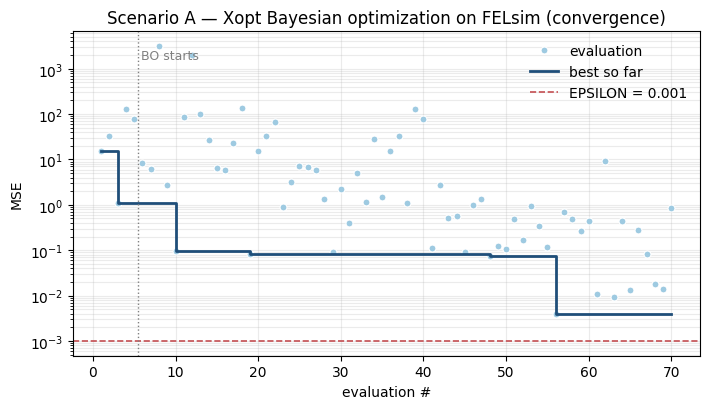

In [8]:
plot_scenario_A_xopt_convergence(X, N_INIT_A)

## Scenario B — 11-stage sequential BO (real FELsim)

Same pipeline as `run_scenario_B` in `scenario_A-C.ipynb` / `scenario_B_utils.py`: the
beamline is optimised **stage by stage** (Doublet → Chromaticity → Triplet → … → UND match).
Each stage sees the beamline slice `bl[:bl_len]`, optimises only its own quads, and the best
currents found are **written back into the shared beamline** before the next stage starts
(Stage 5 additionally mirrors its currents onto elements 39/41/43, exactly as in
`scenario_B_utils.py`). Per stage, `N_INIT_B` random points + `N_BO_STEPS_B` BO steps replace
one `scipy.optimize.minimize` call.

`STAGES_B` is copied verbatim from `scenario_A-C.ipynb`. Its per-stage `start` values are only meaningful for the scipy methods — BO uses the bounds only.

In [ ]:
# # scenario B setting (identical to scenario_A-C.ipynb)
# N_RUNS_B     = 1          # independent repetitions of the whole 11-stage pipeline
# N_INIT_B     = 3          # random initial evaluations per stage
# N_BO_STEPS_B = 25         # BO steps per stage (1 FELsim evaluation each)

# STAGES_B = [
#     (
#         "Stage 1 Doublet",
#         {1: _v("I"), 3: _v("I2")},
#         {
#             8: [
#                 {"measure": ["x", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["x", "beta"], "goal": 0.1, "weight": 0.0},
#             ],
#             9: [
#                 {"measure": ["y", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["y", "beta"], "goal": 0.1, "weight": 0.5},
#             ],
#         },
#         10,
#         {
#             "I": {"bounds": CURRENT_BOUNDS, "start": 1},
#             "I2": {"bounds": CURRENT_BOUNDS, "start": 1},
#         },
#     ),
#     (
#         "Stage 2 Chrom.1",
#         {10: _v("I")},
#         {15: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]},
#         16,
#         {"I": {"bounds": CURRENT_BOUNDS, "start": 1}},
#     ),
#     (
#         "Stage 3 Triplet1",
#         {16: _v("I"), 18: _v("I2"), 20: _v("I3")},
#         {
#             25: [
#                 {"measure": ["x", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["x", "beta"], "goal": 0.1, "weight": 0.5},
#             ],
#             26: [
#                 {"measure": ["y", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["y", "beta"], "goal": 0.1, "weight": 0.5},
#             ],
#         },
#         27,
#         {
#             "I": {"bounds": CURRENT_BOUNDS, "start": 2},
#             "I2": {"bounds": CURRENT_BOUNDS, "start": 5},
#             "I3": {"bounds": CURRENT_BOUNDS, "start": 3},
#         },
#     ),
#     (
#         "Stage 4 Chrom.2",
#         {27: _v("I")},
#         {32: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]},
#         33,
#         {"I": {"bounds": CURRENT_BOUNDS, "start": 1}},
#     ),
#     (
#         "Stage 5 DblTriplet",
#         {37: _v("I"), 35: _v("I2"), 33: _v("I3")},
#         {
#             37: [
#                 {"measure": ["x", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["y", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["x", "envelope"], "goal": 2.0, "weight": 1},
#                 {"measure": ["y", "envelope"], "goal": 2.0, "weight": 1},
#             ]
#         },
#         38,
#         {
#             "I": {"bounds": CURRENT_BOUNDS, "start": 0.28},
#             "I2": {"bounds": CURRENT_BOUNDS, "start": 2.65},
#             "I3": {"bounds": CURRENT_BOUNDS, "start": 2.69},
#         },
#     ),
#     (
#         "Stage 6 Chrom.3",
#         {50: _v("I")},
#         {55: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]},
#         56,
#         {"I": {"bounds": CURRENT_BOUNDS, "start": 1}},
#     ),
#     (
#         "Stage 7 IP",
#         {56: _v("I"), 58: _v("I2")},
#         {
#             59: [
#                 {"measure": ["x", "envelope"], "goal": 0.0, "weight": 1},
#                 {"measure": ["y", "envelope"], "goal": 0.0, "weight": 1},
#             ]
#         },
#         60,
#         {
#             "I": {"bounds": CURRENT_BOUNDS, "start": 2},
#             "I2": {"bounds": CURRENT_BOUNDS, "start": 2},
#         },
#     ),
#     (
#         "Stage 8 Doublet2",
#         {61: _v("I"), 63: _v("I2")},
#         {
#             68: [
#                 {"measure": ["x", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["x", "beta"], "goal": 0.1, "weight": 0.5},
#             ],
#             69: [
#                 {"measure": ["y", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["y", "beta"], "goal": 0.1, "weight": 0.5},
#             ],
#         },
#         70,
#         {
#             "I": {"bounds": CURRENT_BOUNDS, "start": 2},
#             "I2": {"bounds": CURRENT_BOUNDS, "start": 2},
#         },
#     ),
#     (
#         "Stage 9 Chrom.4",
#         {70: _v("I")},
#         {75: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]},
#         76,
#         {"I": {"bounds": CURRENT_BOUNDS, "start": 1}},
#     ),
#     (
#         "Stage 10 Triplet3",
#         {76: _v("I"), 78: _v("I2"), 80: _v("I3")},
#         {
#             85: [
#                 {"measure": ["x", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["x", "beta"], "goal": 0.1, "weight": 0.5},
#             ],
#             86: [
#                 {"measure": ["y", "alpha"], "goal": 0, "weight": 1},
#                 {"measure": ["y", "beta"], "goal": 0.1, "weight": 0.5},
#             ],
#         },
#         87,
#         {
#             "I": {"bounds": CURRENT_BOUNDS, "start": 2},
#             "I2": {"bounds": CURRENT_BOUNDS, "start": 2},
#             "I3": {"bounds": CURRENT_BOUNDS, "start": 2},
#         },
#     ),
#     (
#         "Stage 11 UND Match",
#         {87: _v("Ic"), 93: _v("I"), 95: _v("I2"), 97: _v("I3")},
#         {
#             92: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 0.5}],
#             117: [
#                 {"measure": ["x", "alpha"], "goal": ALPHA_XM, "weight": 1},
#                 {"measure": ["y", "alpha"], "goal": ALPHA_YM, "weight": 1},
#                 {"measure": ["x", "beta"], "goal": BETA_XM, "weight": 1},
#                 {"measure": ["y", "beta"], "goal": BETA_YM, "weight": 1},
#             ],
#         },
#         118,
#         {
#             "Ic": {"bounds": CURRENT_BOUNDS, "start": 4},
#             "I": {"bounds": CURRENT_BOUNDS, "start": 2},
#             "I2": {"bounds": CURRENT_BOUNDS, "start": 2},
#             "I3": {"bounds": CURRENT_BOUNDS, "start": 2},
#         },
#     ),
# ]


In [ ]:
# def run_scenario_B_xopt(STAGES_B, n_runs=1, n_init=2, n_steps=25, seed=SEED, verbose=True):
#     """
#     Xopt/BO counterpart of scenario_B_utils.run_scenario_B.
#     Returns (results, df_B, final_beamline, xopt_data) with the same per-stage record layout;
#     xopt_data[(run, stage)] holds the full Xopt history (X.data) of that stage.
#     """
#     stage_results, xopt_data = [], {}
#     bl_run = None
#     t_total = time.perf_counter()
#     if verbose:
#         print(f"\n▶ 🚀 Starting Scenario B (11-Stage Sequential) — Method: {XOPT_TAG} ({n_runs} runs total)")

#     for run_i in range(n_runs):
#         if verbose and n_runs > 1:
#             print(f"  ── Run {run_i + 1}/{n_runs} ──")
#         bl_run = ExcelElements(EXCEL_PATH).create_beamline()          # fresh beamline for every run
#         run_seed = seed + run_i * 997

#         for s_i, (lbl, seg_var, obj, bl_len, fixed_sp) in enumerate(STAGES_B):
#             evaluate, var_names, _ = make_felsim_evaluator(bl_run[:bl_len], seg_var, obj, CURRENT_BOUNDS_BC)
#             X, st = run_xopt_bo(evaluate, var_names, n_init, n_steps,
#                                 seed=run_seed + s_i, label=lbl, verbose=False)
#             xopt_data[(run_i + 1, s_i + 1)] = X.data.copy()

#             # 🎯 Crucial hand-off: write the best currents back to the shared beamline for the next stage
#             if all(np.isfinite(v) for v in st["best_x"].values()):
#                 for elem_idx, var_info in seg_var.items():
#                     bl_run[elem_idx].current = float(st["best_x"][var_info[0]])
#                 if s_i == 4:                                             # Stage 5 symmetry (as in scenario_B_utils)
#                     bl_run[43].current = bl_run[33].current
#                     bl_run[41].current = bl_run[35].current
#                     bl_run[39].current = bl_run[37].current
#             elif verbose:                                                # every evaluation failed: keep previous currents
#                 print(f"    {lbl:25s} ⚠ all {st['nfev']} evaluations failed — currents left unchanged")

#             rec = {"run": run_i + 1, "stage": s_i + 1, "stage_name": lbl, "method_tag": XOPT_TAG,
#                    "final_mse": st["final_mse"], "nfev": st["nfev"], "nit": st["nfev"],
#                    "wall_time": st["wall_time"], "success": st["success"],
#                    "n_to_eps": st["n_to_eps"], "n_failed": st["n_failed"], "n_fallback": st["n_fallback"],
#                    **st["best_x"]}
#             stage_results.append(rec)
#             if verbose:
#                 extra = f"  (MSE < EPSILON after {st['n_to_eps']} evals)" if st["n_to_eps"] else ""
#                 print(f"    {lbl:25s} MSE={st['final_mse']:.3e}  nfev={st['nfev']:<4} t={st['wall_time']:.2f}s{extra}")

#     if verbose:
#         print(f"✓ {XOPT_TAG} pipeline execution completed, total time: {time.perf_counter() - t_total:.2f}s")
#     df_B = pd.DataFrame(stage_results)
#     return {XOPT_TAG: stage_results}, df_B, bl_run, xopt_data




▶ 🚀 Starting Scenario B (11-Stage Sequential) — Method: Xopt-EI (1 runs total)
    Stage 1 Doublet           MSE=1.410e-01  nfev=28   t=36.95s  (MSE < EPSILON after 10 evals)
    Stage 2 Chrom.1           MSE=4.443e-04  nfev=28   t=23.35s  (MSE < EPSILON after 1 evals)
    Stage 3 Triplet1          MSE=4.720e+01  nfev=28   t=43.18s
    Stage 4 Chrom.2           MSE=5.212e-04  nfev=28   t=44.62s  (MSE < EPSILON after 1 evals)
    Stage 5 DblTriplet        MSE=5.558e-01  nfev=28   t=49.21s  (MSE < EPSILON after 20 evals)
    Stage 6 Chrom.3           MSE=6.122e-12  nfev=28   t=59.90s  (MSE < EPSILON after 1 evals)
    Stage 7 IP                MSE=1.217e+00  nfev=28   t=70.01s
    Stage 8 Doublet2          MSE=4.084e+01  nfev=28   t=74.09s
    Stage 9 Chrom.4           MSE=3.428e-02  nfev=28   t=72.34s  (MSE < EPSILON after 1 evals)
    Stage 10 Triplet3         MSE=2.008e+03  nfev=28   t=90.74s
    Stage 11 UND Match        MSE=4.449e+02  nfev=28   t=157.54s
✓ Xopt-EI pipeline executio

,run,stage,stage_name,method_tag,final_mse,nfev,wall_time,success,n_to_eps,n_failed,n_fallback
0,1,1,Stage 1 Doublet,Xopt-EI,1.409708e-01,28,36.947,True,10.0,0,0
1,1,2,Stage 2 Chrom.1,Xopt-EI,4.443159e-04,28,23.347,True,1.0,0,0
2,1,3,Stage 3 Triplet1,Xopt-EI,4.719501e+01,28,43.176,False,NaN,0,0
3,1,4,Stage 4 Chrom.2,Xopt-EI,5.212279e-04,28,44.622,True,1.0,0,0
4,1,5,Stage 5 DblTriplet,Xopt-EI,5.558251e-01,28,49.214,True,20.0,0,0
5,1,6,Stage 6 Chrom.3,Xopt-EI,6.121516e-12,28,59.897,True,1.0,0,0
6,1,7,Stage 7 IP,Xopt-EI,1.216980e+00,28,70.010,False,NaN,0,0
7,1,8,Stage 8 Doublet2,Xopt-EI,4.083687e+01,28,74.088,False,NaN,0,0
8,1,9,Stage 9 Chrom.4,Xopt-EI,3.428081e-02,28,72.343,True,1.0,0,0
9,1,10,Stage 10 Triplet3,Xopt-EI,2.008228e+03,28,90.741,False,NaN,0,0


In [12]:
# import importlib
# import utils.Xopt_utils
# importlib.reload(utils.Xopt_utils)
# from utils.Xopt_utils import *
results_B_xopt, df_B_xopt, final_beamline_B_xopt, xopt_data_B = run_scenario_B_xopt(
    STAGES_B, CURRENT_BOUNDS_BC, n_runs=N_RUNS_B, n_init=N_INIT_B, n_steps=N_BO_STEPS_B, seed=SEED, verbose=True)

display(df_B_xopt[["run", "stage", "stage_name", "method_tag", "final_mse",
                   "nfev", "wall_time", "success", "n_to_eps", "n_failed", "n_fallback"]])


▶ 🚀 Starting Scenario B (11-Stage Sequential) — Method: Xopt-EI (1 runs total)
    Stage 1 Doublet           MSE=6.039e-02  nfev=28   t=37.57s
    Stage 2 Chrom.1           MSE=4.201e-04  nfev=28   t=19.67s  (MSE < EPSILON after 1 evals)
    Stage 3 Triplet1          MSE=7.425e+00  nfev=28   t=41.33s
    Stage 4 Chrom.2           MSE=3.505e-08  nfev=28   t=36.81s  (MSE < EPSILON after 1 evals)
    Stage 5 DblTriplet        MSE=9.325e-01  nfev=28   t=48.81s
    Stage 6 Chrom.3           MSE=7.833e-11  nfev=28   t=53.65s  (MSE < EPSILON after 3 evals)
    Stage 7 IP                MSE=4.755e-01  nfev=28   t=61.39s
    Stage 8 Doublet2          MSE=5.561e+00  nfev=28   t=81.79s
    Stage 9 Chrom.4           MSE=8.845e-11  nfev=28   t=78.99s  (MSE < EPSILON after 4 evals)
    Stage 10 Triplet3         MSE=4.368e+01  nfev=28   t=85.66s
    Stage 11 UND Match        MSE=2.949e+01  nfev=28   t=121.69s
✓ Xopt-EI pipeline execution completed, total time: 667.76s


,run,stage,stage_name,method_tag,final_mse,nfev,wall_time,success,n_to_eps,n_failed,n_fallback
0,1,1,Stage 1 Doublet,Xopt-EI,6.039153e-02,28,37.571,False,NaN,0,0
1,1,2,Stage 2 Chrom.1,Xopt-EI,4.200616e-04,28,19.674,True,1.0,0,0
2,1,3,Stage 3 Triplet1,Xopt-EI,7.424924e+00,28,41.325,False,NaN,0,0
3,1,4,Stage 4 Chrom.2,Xopt-EI,3.504650e-08,28,36.809,True,1.0,0,0
4,1,5,Stage 5 DblTriplet,Xopt-EI,9.324700e-01,28,48.810,False,NaN,0,0
5,1,6,Stage 6 Chrom.3,Xopt-EI,7.832602e-11,28,53.654,True,3.0,0,0
6,1,7,Stage 7 IP,Xopt-EI,4.755249e-01,28,61.392,False,NaN,0,0
7,1,8,Stage 8 Doublet2,Xopt-EI,5.560811e+00,28,81.793,False,NaN,0,0
8,1,9,Stage 9 Chrom.4,Xopt-EI,8.844759e-11,28,78.993,True,4.0,0,0
9,1,10,Stage 10 Triplet3,Xopt-EI,4.367576e+01,28,85.656,False,NaN,0,0


In [14]:
# # optimised currents per stage (last run) vs. the FELsim S1 reference currents
# last = df_B_xopt[df_B_xopt.run == df_B_xopt.run.max()].set_index("stage")
# rows = []
# for s_i, (lbl, seg_var, obj, bl_len, _) in enumerate(STAGES_B):
#     for elem_idx, var_info in seg_var.items():
#         rows.append({"stage": s_i + 1, "stage_name": lbl, "element": elem_idx, "variable": var_info[0],
#                      "I_xopt (A)": final_beamline_B_xopt[elem_idx].current,
#                      "I_ref (A)": FELSIM_S1_CURRENTS.get(elem_idx, np.nan),
#                      "stage MSE": last.loc[s_i + 1, "final_mse"],
#                      "MSE < EPS": bool(last.loc[s_i + 1, "final_mse"] < EPSILON)})
# currents_B_xopt = pd.DataFrame(rows)

# print(f"Scenario B ({XOPT_TAG}, run {int(df_B_xopt.run.max())}): stages with MSE < {EPSILON:g}: "
#       f"{int(last.success.sum())}/{len(last)}   |   FELsim evaluations: {int(last.nfev.sum())}"
#       f"   |   wall time: {last.wall_time.sum():.0f} s")
# print("(note: many reference currents lie outside CURRENT_BOUNDS, as in scenario_A-C.ipynb)")
# with pd.option_context("display.float_format", lambda v: f"{v:.3e}" if abs(v) < 1e-3 else f"{v:.4f}"):
#     display(currents_B_xopt)
    
import importlib
import utils.Xopt_utils
importlib.reload(utils.Xopt_utils)
from utils.Xopt_utils import *
display_scenario_B_xopt_summary(df_B_xopt, STAGES_B, final_beamline_B_xopt, FELSIM_S1_CURRENTS)

Scenario B (Xopt-EI, run 1): stages with MSE < 0.001: 4/11   |   FELsim evaluations: 308   |   wall time: 667 s
(note: many reference currents lie outside CURRENT_BOUNDS, as in scenario_A-C.ipynb)


,stage,stage_name,element,variable,I_xopt (A),I_ref (A),stage MSE,MSE < EPS
0,1,Stage 1 Doublet,1,I,0.9704,0.8218,0.0604,False
1,1,Stage 1 Doublet,3,I2,1.1728,1.0430,0.0604,False
2,2,Stage 2 Chrom.1,10,I,1.5000,3.8834,4.201e-04,True
3,3,Stage 3 Triplet1,16,I,1.5000,2.2396,7.4249,False
4,3,Stage 3 Triplet1,18,I2,1.5000,4.9532,7.4249,False
5,3,Stage 3 Triplet1,20,I3,0.7041,3.4258,7.4249,False
6,4,Stage 4 Chrom.2,27,I,0.0333,4.6657,3.505e-08,True
7,5,Stage 5 DblTriplet,37,I,1.1955,0.2768,0.9325,False
8,5,Stage 5 DblTriplet,35,I2,1.5000,2.6523,0.9325,False
9,5,Stage 5 DblTriplet,33,I3,0.2359,2.6942,0.9325,False


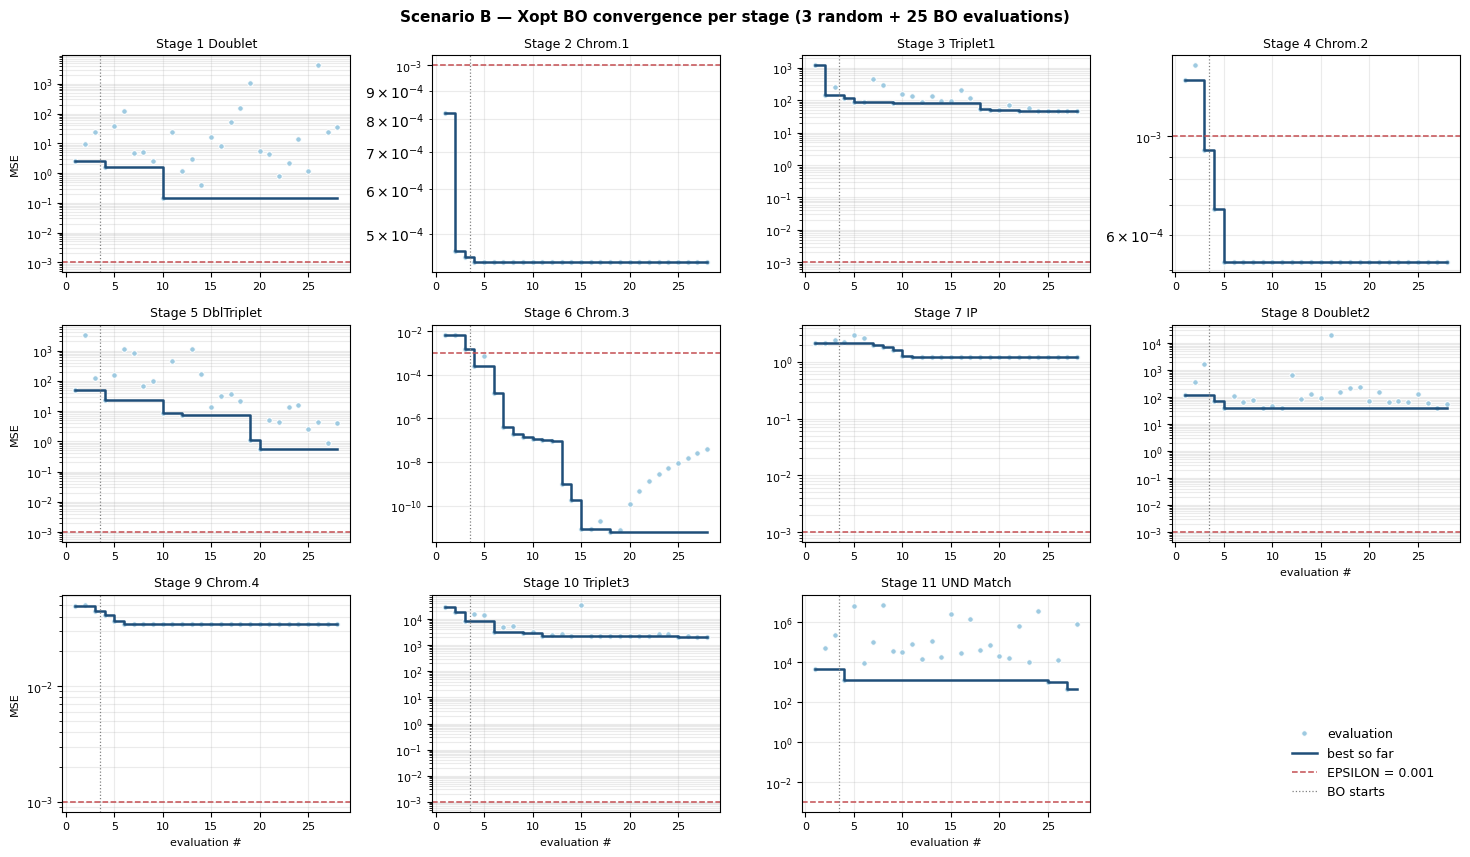

In [ ]:
# # per-stage convergence of the (last) Scenario B run
# def plot_scenario_B_xopt_convergence(df_B_xopt, xopt_data_B, N_INIT_B):
#     run_id = int(df_B_xopt.run.max())
#     n_st = len(STAGES_B)
#     ncols = 4
#     nrows = int(np.ceil(n_st / ncols))
#     fig, axes = plt.subplots(nrows, ncols, figsize=(3.7 * ncols, 2.9 * nrows))
#     axes = np.atleast_1d(axes).ravel()
#     for s_i in range(n_st):
#         bo_convergence_plot(axes[s_i], xopt_data_B[(run_id, s_i + 1)], N_INIT_B, title=STAGES_B[s_i][0])
#         if s_i % ncols == 0:
#             axes[s_i].set_ylabel("MSE", fontsize=8)
#         if s_i >= n_st - ncols:
#             axes[s_i].set_xlabel("evaluation #", fontsize=8)
#     for ax in axes[n_st:]:
#         ax.axis("off")
#     handles, labels = axes[0].get_legend_handles_labels()
#     fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.98, 0.06), frameon=False, fontsize=9)
#     fig.suptitle(f"Scenario B — Xopt BO convergence per stage ({N_INIT_B} random + {N_BO_STEPS_B} BO evaluations)",
#                 fontsize=11, fontweight="bold")
#     plt.tight_layout()
#     plt.show()

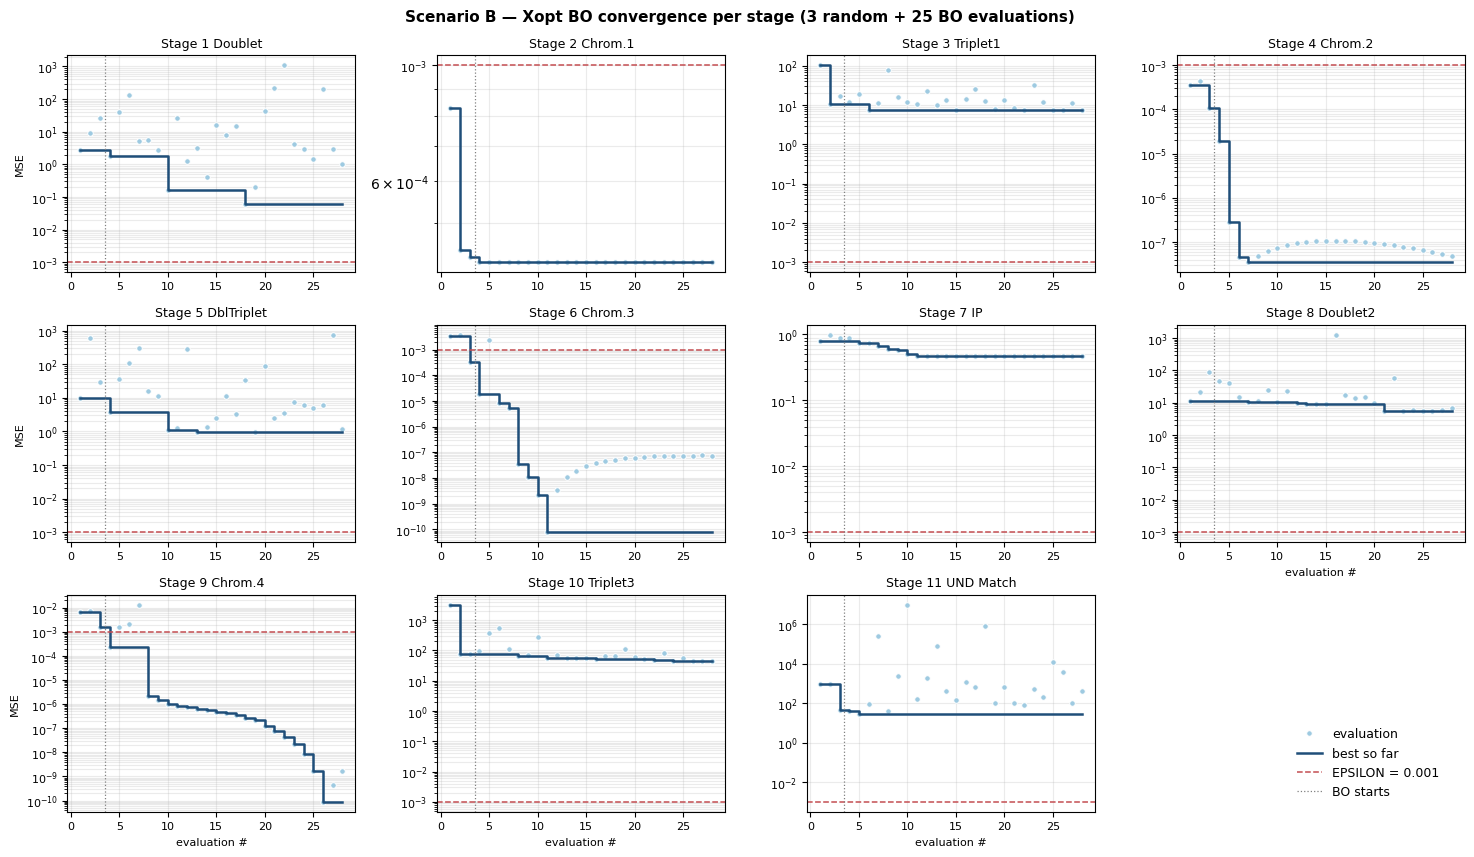

In [15]:
plot_scenario_B_xopt_convergence(STAGES_B, df_B_xopt, xopt_data_B, N_INIT_B)

## Scenario C — combined 11-parameter

Same problem as `run_scenario_C` in `scenario_A-C.ipynb`: all **11 quad currents** of the
IP + UND section (elements 56 … 97) are optimised **simultaneously** over the 118-element
beamline against 6 objectives (IP spot size at element 59 + UND Twiss matching at element 117).
One BO run (`N_INIT_C` random points + `N_BO_STEPS_C` steps) replaces one
`scipy.optimize.minimize` call.

In [ ]:

# scenario C setting (identical to scenario_A-C.ipynb)
# C_BEAMLINE_LEN = 118
# N_RUNS_C     = 1
# N_INIT_C     = 22        # random initial evaluations (= number of variables)
# N_BO_STEPS_C = 200        # BO steps (1 FELsim evaluation each)

# # Ensure variables are uniquely named to prevent DataFrame column collisions
# def _v_C(name): return [name, "current", lambda x, _n=name: x]

# C_VARS = {
#     56: _v_C("I_56"), 58: _v_C("I_58"),
#     61: _v_C("I_61"), 63: _v_C("I_63"),
#     76: _v_C("I_76"), 78: _v_C("I_78"), 80: _v_C("I_80"),
#     87: _v_C("I_87"), 93: _v_C("I_93"), 95: _v_C("I_95"), 97: _v_C("I_97")
# }

# # Objectives: IP spot + UND beta matching
# C_OBJ = {
#     59: [
#         {"measure": ["x", "envelope"], "goal": 0.0, "weight": 1.0},
#         {"measure": ["y", "envelope"], "goal": 0.0, "weight": 1.0},
#     ],
#     117: [
#         {"measure": ["x", "alpha"], "goal": ALPHA_XM, "weight": 1.0},
#         {"measure": ["y", "alpha"], "goal": ALPHA_YM, "weight": 1.0},
#         {"measure": ["x", "beta"], "goal": BETA_XM, "weight": 1.0},
#         {"measure": ["y", "beta"], "goal": BETA_YM, "weight": 1.0},
#     ]
# }

In [ ]:
# def run_scenario_C_xopt(VARS, OBJ, beamline_len, ref_currents, n_runs=1, n_init=11, n_steps=60,
#                         seed=SEED, verbose=True):
#     """
#     Xopt/BO counterpart of experiments_utils.run_scenario_C (single stage, all variables at once).
#     Returns (results, df_C, final_summary, xopt_data); records follow run_benchmark's layout:
#     'mse_curve' is the raw MSE of every evaluation (NaN where FELsim failed), exactly like
#     run_benchmark's list(opti.plotMSE), so plot_stat_convergence from experiments_utils can be
#     used on them; 'best_mse_curve' additionally holds the best-so-far envelope used for BO plots.
#     """
#     var_names = list(dict.fromkeys(v[0] for v in VARS.values()))
#     out_names = measured_names(OBJ)
#     results, xopt_data = [], {}
#     if verbose:
#         print(f"\n▶ Scenario C — {XOPT_TAG}  ({n_runs} runs)")

#     for run_i in range(n_runs):
#         bl = ExcelElements(EXCEL_PATH).create_beamline()[:beamline_len]
#         evaluate, _, _ = make_felsim_evaluator(bl, VARS, OBJ, CURRENT_BOUNDS_BC)
#         X, st = run_xopt_bo(evaluate, var_names, n_init, n_steps, seed=seed + run_i * 997,
#                             label="Scenario C", verbose=verbose)
#         xopt_data[run_i + 1] = X.data.copy()
#         best = X.data.iloc[st["best_eval"] - 1] if st["best_eval"] > 0 else None
#         raw_mse = X.data["MSE"].to_numpy(dtype=float)                   # NaN where FELsim failed
#         rec = {"run": run_i + 1, "method": XOPT_TAG, "scenario": "C", "method_tag": XOPT_TAG,
#                "final_mse": st["final_mse"], "nfev": st["nfev"], "nit": st["nfev"],
#                "wall_time": st["wall_time"], "success": st["success"],
#                "n_to_eps": st["n_to_eps"], "n_failed": st["n_failed"], "n_fallback": st["n_fallback"],
#                "mse_curve": [float(v) for v in raw_mse],
#                "best_mse_curve": [float(v) for v in np.minimum.accumulate(np.nan_to_num(raw_mse, nan=np.inf))],
#                "result_x": st["best_x"], **st["best_x"],
#                **{n: (float(best[n]) if best is not None else np.nan) for n in out_names}}
#         results.append(rec)
#         if verbose:
#             print(f"  {XOPT_TAG:22s}  run {run_i + 1}/{n_runs}  MSE={st['final_mse']:.3e}  "
#                   f"nfev={st['nfev']:<4} t={st['wall_time']:.2f}s  "
#                   f"(failed evals: {st['n_failed']}, random fallbacks: {st['n_fallback']})")

#     df_C = pd.DataFrame(results)

#     # summary in the spirit of run_scenario_C's final_summary: metrics + champion currents vs reference
#     best_run = df_C.loc[df_C["final_mse"].fillna(np.inf).idxmin()]     # all-NaN safe (row 0 -> NaN table)
#     final_summary = pd.DataFrame([{
#         "method_tag": XOPT_TAG,
#         "conv_rate": float(df_C["success"].mean()),
#         "nfev_mean": float(df_C["nfev"].mean()),
#         "wall_time_mean": float(df_C["wall_time"].mean()),
#         "final_mse_best": float(best_run["final_mse"]),
#         **{k: v for n in var_names for k, v in ((n, float(best_run[n])),)},
#         **{f"{n}_ref": ref_currents[elem] for elem, v in VARS.items() for n in [v[0]]},
#         **{n: float(best_run[n]) for n in out_names},
#     }])
#     return {XOPT_TAG: results}, df_C, final_summary, xopt_data



In [20]:
import importlib
import utils.Xopt_utils
importlib.reload(utils.Xopt_utils)
from utils.Xopt_utils import *
N_BO_STEPS_C=200

results_C_xopt, df_C_xopt, final_summary_C_xopt, xopt_data_C = run_scenario_C_xopt(
    C_VARS, C_OBJ, C_BEAMLINE_LEN, FELSIM_S1_CURRENTS, CURRENT_BOUNDS_BC,
    n_runs=N_RUNS_C, n_init=N_INIT_C, n_steps=N_BO_STEPS_C, seed=SEED, verbose=True)

# print("\n" + "=" * 100)
# print(f" 🎯 SCENARIO C ({XOPT_TAG}): Robustness (Tol < {EPSILON}) & Discovered Physics State vs Reference")
# print("=" * 100)
# s = final_summary_C_xopt.iloc[0]
# print(f" conv_rate={s.conv_rate:.0%}   nfev_mean={s.nfev_mean:.1f}   wall_time_mean={s.wall_time_mean:.1f} s"
#       f"   best MSE={s.final_mse_best:.3e}")

# # champion currents vs reference (one row per quad, easier to read than the wide table)
# cur_names = list(dict.fromkeys(v[0] for v in C_VARS.values()))
# currents_C_xopt = pd.DataFrame({
#     "element": list(C_VARS.keys()), "variable": cur_names,
#     "I_xopt (A)": [float(s[n]) for n in cur_names],
#     "I_ref (A)": [FELSIM_S1_CURRENTS[e] for e in C_VARS],
# })
# display(currents_C_xopt.round(4))

# # measured quantities of the champion point vs their goals
# goals = [(f"{e}_{t['measure'][1]}_{t['measure'][0]}", t["goal"]) for e, ts in C_OBJ.items() for t in ts]
# measured_C_xopt = pd.DataFrame({"quantity": [g[0] for g in goals],
#                                 "measured": [float(s[g[0]]) for g in goals],
#                                 "goal": [float(g[1]) for g in goals]})
# display(measured_C_xopt.round(4))


▶ Scenario C — Xopt-EI  (1 runs)
      Scenario C         BO step   5/200   best MSE = 9.486e+06
      Scenario C         BO step  10/200   best MSE = 9.486e+06
      Scenario C         BO step  15/200   best MSE = 9.486e+06
      Scenario C         BO step  20/200   best MSE = 9.486e+06
      Scenario C         BO step  25/200   best MSE = 9.486e+06
      Scenario C         BO step  30/200   best MSE = 9.486e+06
      Scenario C         BO step  35/200   best MSE = 9.486e+06
      Scenario C         BO step  40/200   best MSE = 9.486e+06
      Scenario C         BO step  45/200   best MSE = 9.486e+06
      Scenario C         BO step  50/200   best MSE = 9.486e+06
      Scenario C         BO step  55/200   best MSE = 9.486e+06
      Scenario C         BO step  60/200   best MSE = 9.486e+06
      Scenario C         BO step  65/200   best MSE = 2.792e+06
      Scenario C         BO step  70/200   best MSE = 2.792e+06
      Scenario C         BO step  75/200   best MSE = 2.792e+06
      

In [18]:
display_scenario_C_xopt_summary(final_summary_C_xopt, C_VARS, FELSIM_S1_CURRENTS)


 🎯 SCENARIO C (Xopt-EI): Robustness (Tol < 0.001) & Discovered Physics State vs Reference
 conv_rate=0%   nfev_mean=27.0   wall_time_mean=114.7 s   best MSE=9.486e+06


,element,variable,I_xopt (A),I_ref (A)
0,56,I_56,0.0463,3.1219
1,58,I_58,1.4347,3.3129
2,61,I_61,1.2918,5.1775
3,63,I_63,0.8913,4.0434
4,76,I_76,0.9323,3.9336
5,78,I_78,0.2236,4.0787
6,80,I_80,0.7814,0.0139
7,87,I_87,0.3547,1.3624
8,93,I_93,0.1688,0.9452
9,95,I_95,1.2856,2.8851


,quantity,measured,goal
0,59_envelope_x,4.3689,0.0000
1,59_envelope_y,5.9845,0.0000
2,117_alpha_x,-4771.8977,0.4700
3,117_alpha_y,-3035.4800,0.0000
4,117_beta_x,4495.4130,1.4000
5,117_beta_y,2174.4717,0.2418


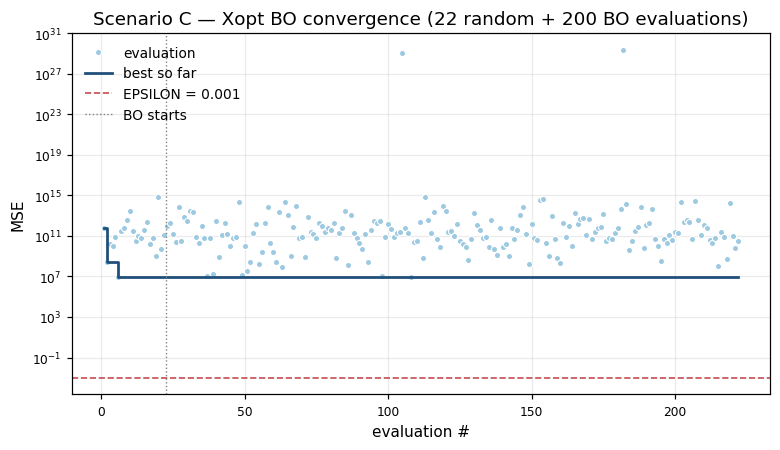

In [ ]:
# def plot_scenario_C_xopt_convergence(df_C_xopt, xopt_data_C, N_INIT_C):

#     fig, ax = plt.subplots(figsize=(7.2, 4.2))
#     bo_convergence_plot(ax, xopt_data_C[int(df_C_xopt.run.max())], N_INIT_C)
#     ax.set_xlabel("evaluation #")
#     ax.set_ylabel("MSE")
#     ax.set_title(f"Scenario C — Xopt BO convergence ({N_INIT_C} random + {N_BO_STEPS_C} BO evaluations)")
#     ax.legend(frameon=False, fontsize=9)
#     plt.tight_layout()
#     plt.show()

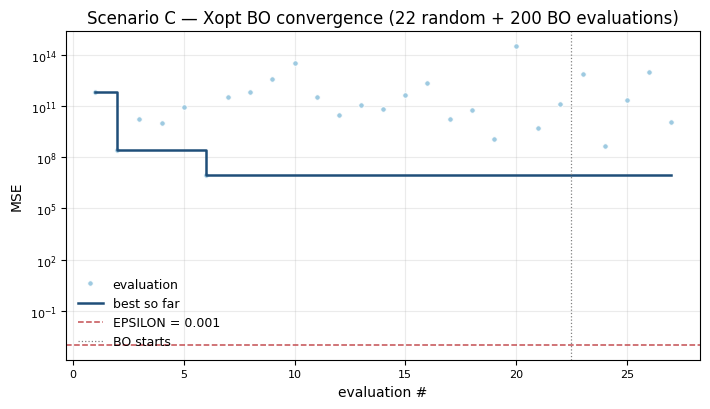

In [19]:
plot_scenario_C_xopt_convergence(df_C_xopt, xopt_data_C, N_INIT_C)